## ressoures
https://matplotlib.org/stable/gallery/color/named_colors.html
https://www.python-graph-gallery.com/web-horizontal-barplot-with-labels-the-economist

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import lines
from matplotlib import patches
from matplotlib.patheffects import withStroke

In [32]:
# Creating a DataFrame from the CSV Dataset
df = pd.read_csv("bayes_factor.csv")

#df['label'] = df['Sequences'] + '_' + df['Model'] + '_' + df['Dataset']
df['label'] = df['Sequences'] + ' ' + df['Model']

df.head()

,Dataset,Sequences,Model,Date vs no date,date vs shuffle,no date vs shuffle,label
0,With variants,Genome,Relaxed lognormal,79.8,84.0,4.2,Genome Relaxed lognormal
1,With variants,Genome,Strict,71.2,83.6,12.4,Genome Strict
2,With variants,Gene S,Relaxed lognormal,35.2,40.6,5.4,Gene S Relaxed lognormal
3,With variants,Gene S,Strict,34.0,41.5,7.5,Gene S Strict
4,With variants,RBD,Relaxed lognormal,41.7,46.7,5.0,RBD Relaxed lognormal


In [33]:
params = {'figure.figsize'  : (50, 40),
          'axes.labelsize'  : 30,
          'axes.titlesize'  : 30,
          'xtick.labelsize' : 20,
          'ytick.labelsize' : 20}
plt.rcParams.update(params)

In [34]:
#fig.savefig('test.svg', format='svg', dpi=1200)

In [35]:
def color_conditions(dataframe, bayes):
    color = 'grey'
    if dataframe[bayes] < -20:
        color =  '#b2182b'
    elif -20< dataframe[bayes] < -3:
        color = '#ef8a62'
    elif -3 < dataframe[bayes] < 0:
        color = '#fddbc7'
    elif dataframe[bayes]  == 0:
        color = 'grey'
    elif 0 < dataframe[bayes] < 3:
        color = '#d1e5f0'
    elif 3 < dataframe[bayes] < 20:
        color = '#67a9cf'
    elif 20 < dataframe[bayes]:
        color = '#2166ac'

    return color

In [36]:
#def color_conditions(dataframe, bayes):
#    color = 'grey'
#    if dataframe[bayes] < -20:
#        color =  'darkred'
#    elif -20< dataframe[bayes] < -3:
#        color = 'firebrick'
#    elif -3 < dataframe[bayes] < 0:
#        color = 'indianred'
#    elif dataframe[bayes]  == 0:
#        color = 'grey'
#    elif 0 < dataframe[bayes] < 3:
#        color = 'lightgreen'
#    elif 3 < dataframe[bayes] < 20:
#        color = 'forestgreen'
#    elif 20 < dataframe[bayes]:
#        color = 'darkgreen'
#
#    return color

In [37]:
def create_graph(df, bayes):
    # The positions for the bars
    # This allows us to determine exactly where each bar is located
    y = [i * 0.7 for i in range(len(df['label']))]
    xn = y
    fig, ax = plt.subplots(figsize=(14, 10))

    #setup colors for bars
    df['color'] = df.apply(color_conditions, args=(bayes ,), axis=1)

    ax.barh(xn, df[bayes], height=0.55, align="edge", color=df['color'])#hatch = '/'
    plt.yticks(xn, df['label'])

    #ax.barh(df['label'], df['Date vs no date'], height=0.55, align="edge", color=df['color'])
    ax.invert_yaxis()

    #################################################################

    #set ticks
    #ticks = [-20, -3, 0, 3, 20]
    #ticks_label = [-20, -3, 0, 3, 20]

    lowest_10s = round(min(df[bayes])/10)
    highest_10s = round(max(df[bayes])/10)
    ticks = [i * 10 for i in range(min(0, lowest_10s) - 1, max(3, highest_10s + 1))]
    ax.xaxis.set_ticks(ticks)
    ax.xaxis.set_ticklabels(ticks, size=16, fontweight=100)
    ax.xaxis.set_tick_params(labelbottom=False, labeltop=True, length=0)

    ax.set_xlim(min(0, (min(df[bayes])) - 5), max(21, max(df[bayes]) + 5))
    #ax.set_xlim((-30, 90))
    #ax.set_ylim((0, len(df['label']) * 0.9 - 0.2))

    # Set whether axis ticks and gridlines are above or below most artists.
    ax.set_axisbelow(True)
    ax.grid(axis = "x", color="#A8BAC4", lw=1.2)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_lw(1)
    # This capstyle determines the lines don't go beyond the limit we specified
    # see: https://matplotlib.org/stable/api/_enums_api.html?highlight=capstyle#matplotlib._enums.CapStyle
    ax.spines["left"].set_capstyle("butt")

    # Hide y labels
    ax.yaxis.set_visible(False)


    #################################################################
    PAD = 0.3
    for label, B_factor, y_pos in zip(df['label'], df[bayes], y):

        if B_factor > 0:
            x = 0
            color = "black"
            path_effects = None

            if 0 < B_factor < 8:
                x = B_factor
                color = 'black'    
                path_effects=[withStroke(linewidth=6, foreground="white")]

            ax.text(
            x + PAD, y_pos + 0.5 / 2, label, 
            color=color, fontsize=18, va="center",
            path_effects=path_effects)
        
        else:
            x = 0
            color = "black"
            path_effects = None

            if -12 < B_factor < 0:
                x = B_factor
                color = 'black'
                path_effects=[withStroke(linewidth=6, foreground="white")]

            ax.text(
            x - PAD, y_pos + 0.5 / 2, label, 
            color=color, fontsize=18, va="center", ha = 'right',
            path_effects=path_effects)
        
        

    # where some data has already been plotted to ax
    handles, labels = ax.get_legend_handles_labels()

    # manually define a new patch 
    legend_dict = {'#b2182b' : 'Strong support against temporal structure',
            '#ef8a62' : 'Positive support against temporal structure',
            '#fddbc7' : 'Barely any support against temporal structure',
            '#d1e5f0' : 'Barely any support for temporal structure',
            '#67a9cf' : 'Positive support for temporal structure',
            '#2166ac' : 'Strong support for temporal structure'
            }

    for col, meaning in legend_dict.items():
        patch = patches.Patch(color=col, label=meaning)

        # handles is a list, so append manual patch
        handles.append(patch) 

    # plot the legend
    if df.at[df.index[0], 'Dataset'] == 'With variants':
        legend_pos = 'best' #'lower right'
    else:
        legend_pos = 'best' #'lower right'
    ax.legend(handles=handles, loc=legend_pos, fontsize = 14)
    
    #####################################################################################

    # Make room on top and bottom
    # Note there's no room on the left and right sides
    fig.subplots_adjust(left=0.005, right=1, top=0.85, bottom=0.1)

    # Add title
    fig.text(
        0, 0.925, "Bayesian Evaluation of Temporal Signal (BETS) results for the six datasets", fontsize=22, fontweight="bold")
    # Add subtitle
    #fig.text(
    #    0, 0.855, "Negative Bayes factors support the $H_{0}$ hypothesis against temporal structure \n" \
    #    "Positive Bayes factors support the $H_{1}$ hypothesis in favor of temporal structure", fontsize=18)
    

    #plt.annotate(r"$\}$",fontsize=24, xy=(0.27, 0.77), xycoords='figure fraction')
    # date vs no date
    plt.annotate("with SARS-CoV-2 \n variants",fontsize=24, xy=(0.05, 0.5), xycoords='figure fraction', path_effects= [withStroke(linewidth=6, foreground="white")])
    plt.annotate("without SARS-CoV-2 \n variants",fontsize=24, xy=(0.61, 0.18), xycoords='figure fraction', path_effects= [withStroke(linewidth=6, foreground="white")])

    # date vs shuffle
    #plt.annotate("with SARS-CoV-2 \n variants",fontsize=24, xy=(0.05, 0.5), xycoords='figure fraction', path_effects= [withStroke(linewidth=6, foreground="white")])
    #plt.annotate("without SARS-CoV-2 \n variants",fontsize=24, xy=(0.61, 0.18), xycoords='figure fraction', path_effects= [withStroke(linewidth=6, foreground="white")])


    # Add caption
    #source = "Sources: Laboratory-Acquired Infection Database; American Biological Safety Association"
    #fig.text(0, 0.06, source, color='grey', fontsize=14,)

    # Add authorship
    #fig.text(0, 0.005, "The Economist", color='grey', fontsize=16)

    # Add line and rectangle on top.
    #fig.add_artist(lines.Line2D([0, 1], [1, 1], lw=3, color='red', solid_capstyle="butt"))
    #fig.add_artist(patches.Rectangle((0, 0.975), 0.05, 0.025, color='red'))

    # Set facecolor, useful when saving as .png
    fig.set_facecolor("white")

    plt.savefig('300dpi.svg', dpi=300)

    fig



In [38]:
#df_variants = df.drop(df[df.Dataset != 'With variants'].index)
#create_graph(df_variants, bayes = 'Date vs no date')

#df_NoVariants = df.drop(df[df.Dataset == 'With variants'].index)
#create_graph(df_NoVariants, bayes = 'Date vs no date')

#create_graph(df, bayes = 'date vs shuffle')

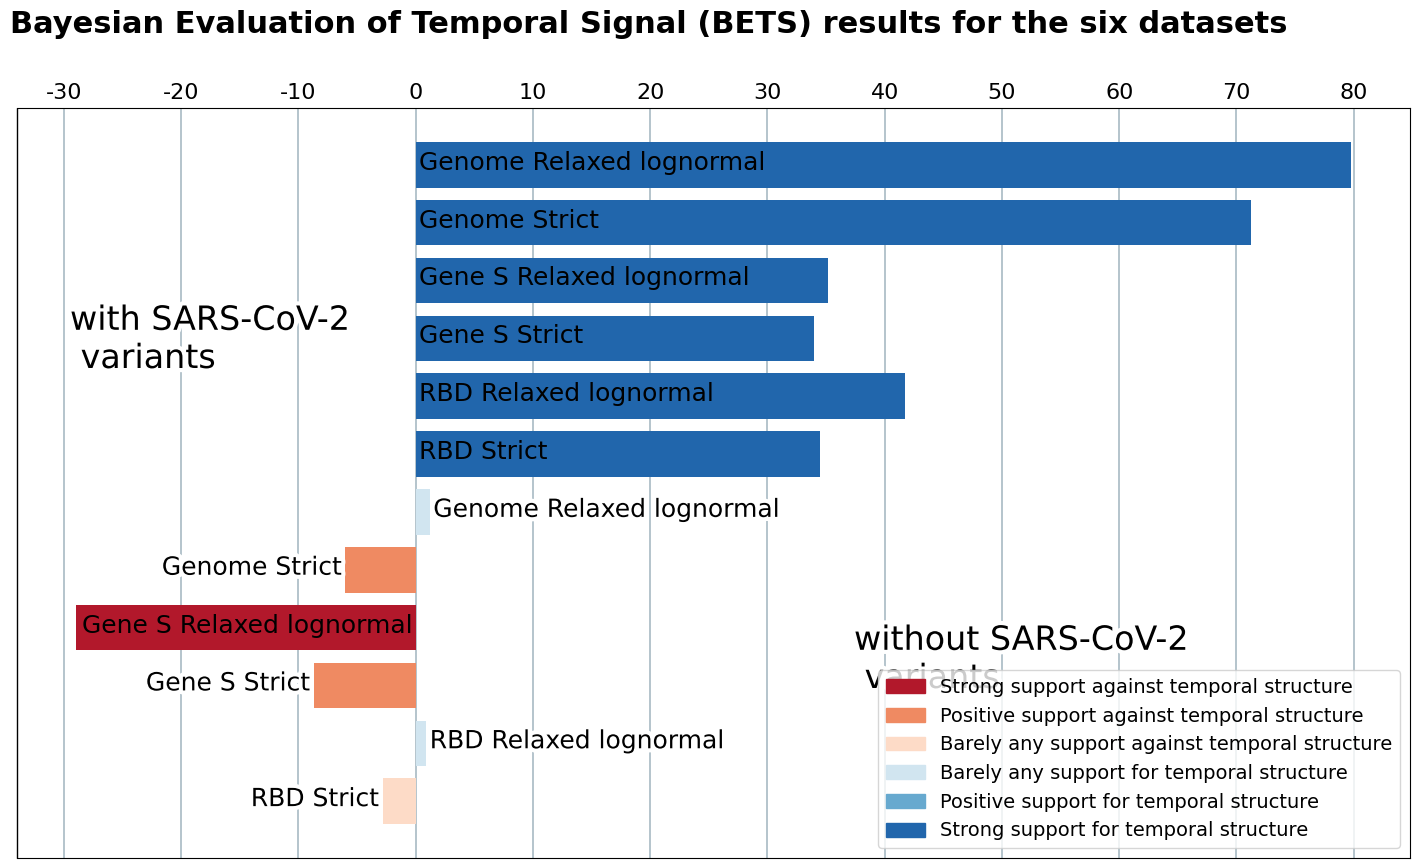

In [39]:
#bayes = 'Date vs no date'
#bayes = 'date vs shuffle'
#bayes = 'no date vs shuffle'

df_variants = df.drop(df[df.Dataset != 'With variants'].index)
#create_graph(df_variants, bayes = 'Date vs no date')

df_NoVariants = df.drop(df[df.Dataset == 'With variants'].index)
#create_graph(df_NoVariants, bayes = 'Date vs no date')

create_graph(df, bayes = 'Date vs no date')

In [40]:
plt.savefig('300dpi_output.svg', dpi=300)

<Figure size 5000x4000 with 0 Axes>

--------
grayscale
-----------